Regressione k-NN

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [7]:
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target


Xdf = pd.DataFrame(X, columns=data.feature_names)
display(Xdf)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [8]:
# scaliamo i dati

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# utilizziamo diversi k per allenare il modello, poi faremo elbow method per vedere punto di flesso

k_range = range(1,20)
mse_values=[]

for k in k_range:
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_scaled, y)
    y_pred = knn_reg.predict(X_scaled)
    mse = mean_squared_error(y, y_pred)
    mse_values.append(mse)

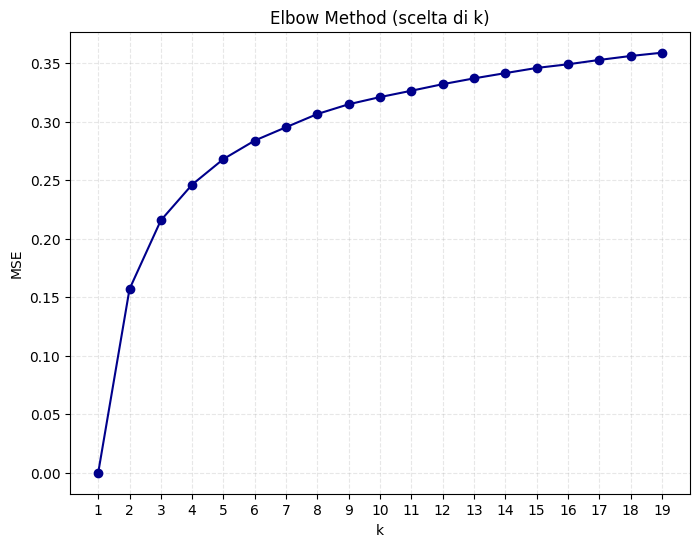

In [10]:
plt.figure(figsize=(8,6))
plt.plot(k_range, mse_values, marker="o", linestyle="-", color="darkblue")
plt.title("Elbow Method (scelta di k)")
plt.xlabel("k")
plt.ylabel("MSE")
plt.xticks(k_range)
plt.grid(linestyle="--", alpha=0.3)
plt.show()

In [11]:
best_k = 7

knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_scaled, y)

y_pred_final = knn_final.predict(X_scaled)

mse_final = mean_squared_error(y, y_pred_final)
r2_final = r2_score(y, y_pred_final)

print(f"k:\t{best_k}\nMSE:\t{mse_final:.4f}\nR2:\t{r2_final:.4f}")

k:	7
MSE:	0.2954
R2:	0.7781


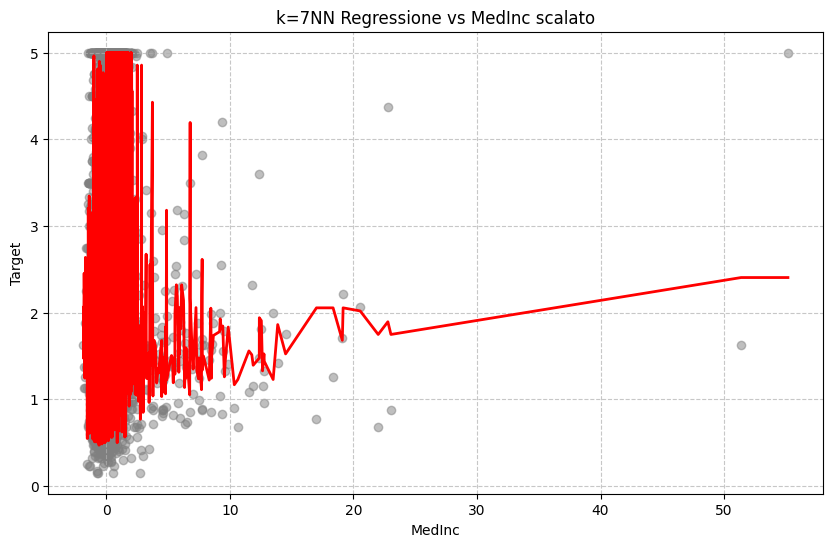

In [14]:
# scegliamo una singola feature per fare il plot del modello. 
# usiamo il MedInc perché è la feature più significativa

feature_index = 2

sort_index = X_scaled[:, feature_index].argsort()
X_plot = X_scaled[sort_index, feature_index]
y_pred_plot = y_pred_final[sort_index]

plt.figure(figsize=(10,6))
# plot dei punti reali
plt.scatter(X_scaled[:, feature_index], y, color="grey", alpha=0.5, label="Real Data Points")
# plot dei punti predetti
plt.plot(X_plot, y_pred_plot, color="red", linewidth=2, label ="Regressione kNN")
plt.title(f"k={best_k}NN Regressione vs MedInc scalato")
plt.xlabel("MedInc")
plt.ylabel("Target")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [15]:
# calcolo errore assoluto percentuale medio (mean absolute percentage error - mape)

import numpy as np
percentage_errors = np.abs((y- y_pred_final) /y)
mape = np.mean(percentage_errors) * 100

print(f"MAPE:\t{mape}%")

MAPE:	20.095450681612565%
